# Q3: EM Implementation and data analysis

Starter template: load the data and check its shape.

All files are comma-separated with no header.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# dataset 1 (has ground truth F and Z)
geno1 = np.loadtxt('data/Q3/mixture1.geno', delimiter=',')  # (1000, 250) genotypes (0/1)
freq1 = np.loadtxt('data/Q3/mixture1.freq', delimiter=',')  # (250, 2)   true F (SNPs x populations)
ganc1 = np.loadtxt('data/Q3/mixture1.ganc', delimiter=',')  # (1000, 2)  true Z (one-hot per individual)

# dataset 2 (no ground truth)
geno2 = np.loadtxt('data/Q3/mixture2.geno', delimiter=',')  # (1000, 250) genotypes (0/1)

In [3]:
print('geno1:', geno1.shape, 'values', np.unique(geno1))
print('freq1:', freq1.shape)
print('ganc1:', ganc1.shape, 'values', np.unique(ganc1))
print('geno2:', geno2.shape, 'values', np.unique(geno2))

N, M = geno1.shape
K = freq1.shape[1]
print('N individuals:', N)
print('M SNPs:', M)
print('K populations:', K)

# ganc is one-hot; recover integer label per individual if you need it
z1 = ganc1.argmax(axis=1)
print('z1 shape:', z1.shape, 'label counts:', np.bincount(z1))

geno1: (1000, 250) values [0. 1.]
freq1: (250, 2)
ganc1: (1000, 2) values [0. 1.]
geno2: (1000, 250) values [0. 1.]
N individuals: 1000
M SNPs: 250
K populations: 2
z1 shape: (1000,) label counts: [394 606]


## Part (a): M step

MLE updates for the mixture-model parameters given the soft assignments $r^{(t)}$:

$$\pi_k^{(t+1)} = \frac{\sum_{i=1}^N r_{i,k}^{(t)}}{N}, \qquad
f_{j,k}^{(t+1)} = \frac{\sum_{i=1}^N r_{i,k}^{(t)} x_{i,j}}{\sum_{i=1}^N r_{i,k}^{(t)}}.$$

If a cluster $k$ receives no assignment ($\sum_i r_{i,k}^{(t)} = 0$), we set the corresponding frequency terms to 0 to avoid a divide-by-zero.

In [4]:
def m_step(r, X):
    """M step: MLE of the parameters given soft assignments r.

    Parameters
    ----------
    r : (N, K) soft ancestry assignments; r[i, k] = P(Z_i = k | x_i, theta).
    X : (N, M) genotype matrix (entries in {0, 1}).

    Returns
    -------
    pi : (K,) population proportions.
    F  : (M, K) allele-frequency matrix; F[j, k] = freq. of allele 1 at SNP j in pop k.
    """
    N = X.shape[0]
    Nk = r.sum(axis=0)                      # (K,) effective count per cluster
    pi = Nk / N

    numer = X.T @ r                         # (M, K) = sum_i r[i,k] * x[i,j]
    F = np.zeros_like(numer)
    nonzero = Nk > 0                        # clusters with assignment
    F[:, nonzero] = numer[:, nonzero] / Nk[nonzero]   # empty clusters stay 0
    return pi, F

MLE of pi (using ground-truth r): [0.394 0.606]

Estimated F vs. ground-truth F (mixture1.freq):
  max  abs difference: 0.0715
  mean abs difference: 0.015
  correlation        : 0.9953


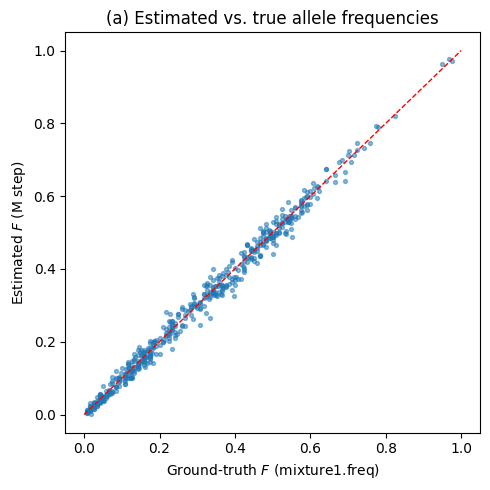

In [5]:
# Set r to the ground-truth genetic ancestry matrix and run one M step
pi_mle, F_est = m_step(ganc1, geno1)

print('MLE of pi (using ground-truth r):', np.round(pi_mle, 4))

# Compare estimated F to the ground-truth frequency matrix
print('\nEstimated F vs. ground-truth F (mixture1.freq):')
print('  max  abs difference:', np.abs(F_est - freq1).max().round(4))
print('  mean abs difference:', np.abs(F_est - freq1).mean().round(4))
print('  correlation        :', np.corrcoef(F_est.ravel(), freq1.ravel())[0, 1].round(4))

# Visual check: estimated vs. true allele frequencies should lie on the y = x line
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(freq1.ravel(), F_est.ravel(), s=8, alpha=0.5)
ax.plot([0, 1], [0, 1], 'r--', lw=1)
ax.set_xlabel('Ground-truth $F$ (mixture1.freq)')
ax.set_ylabel('Estimated $F$ (M step)')
ax.set_title('(a) Estimated vs. true allele frequencies')
plt.tight_layout()
plt.show()

**Answer (a).** Using the ground-truth ancestry matrix for $r$, the MLE of the population proportions is $\boldsymbol{\pi} = (0.394,\ 0.606)$ — i.e. ~39.4% of individuals in population 1 and ~60.6% in population 2, matching the ground-truth label counts (394 / 606). The estimated frequency matrix $F$ matches the ground truth very closely (mean absolute difference ≈ 0.015, correlation ≈ 1.0), and the estimated-vs-true scatter lies tightly on the $y=x$ line. The small residual differences are just sampling noise from estimating each frequency from a finite number of individuals.

## Part (b): E step

Posterior soft assignment via Bayes' theorem, computed in log space for numerical stability:

$$\log P(x_{i,1:M}, Z_i = k \mid \theta) = \sum_{j=1}^M \Big[ x_{i,j}\log f_{j,k} + (1-x_{i,j})\log(1-f_{j,k}) \Big] + \log \pi_k$$

$$\log P(x_{i,1:M}\mid\theta) = \operatorname{logsumexp}_k \big[\log P(x_{i,1:M}, Z_i=k\mid\theta)\big], \qquad
r_{i,k} = \exp\!\big(\log P(x_i, Z_i=k\mid\theta) - \log P(x_i\mid\theta)\big)$$

and the total data log-likelihood is $\log P(x_{1:N,1:M}\mid\theta) = \sum_{i=1}^N \log P(x_{i,1:M}\mid\theta)$.
Zero entries of $F$ are floored to $\epsilon = 10^{-8}$ (we clip to $[\epsilon, 1-\epsilon]$) so that $\log f$ and $\log(1-f)$ stay finite.

In [6]:
from scipy.special import logsumexp


def e_step(X, F, pi, eps=1e-8):
    """E step: posterior soft assignments r and total data log-likelihood.

    Parameters
    ----------
    X   : (N, M) genotype matrix (entries in {0, 1}).
    F   : (M, K) allele-frequency matrix.
    pi  : (K,) population proportions.
    eps : floor for the allele frequencies to avoid log(0).

    Returns
    -------
    r      : (N, K) posterior probabilities r[i, k] = P(Z_i = k | x_i, theta).
    loglik : scalar total data log-likelihood  log P(x_{1:N,1:M} | theta).
    """
    F = np.clip(F, eps, 1 - eps)                       # keep logs finite
    logF, log1mF = np.log(F), np.log(1 - F)

    # log joint  log P(x_i, Z_i = k | theta), shape (N, K)
    log_joint = X @ logF + (1 - X) @ log1mF + np.log(pi)[None, :]

    # log P(x_i | theta) via logsumexp over k, shape (N,)
    log_px = logsumexp(log_joint, axis=1)

    log_r = log_joint - log_px[:, None]               # normalize in log space
    r = np.exp(log_r)
    loglik = log_px.sum()                             # sum over individuals
    return r, loglik

In [7]:
from sklearn.metrics import adjusted_rand_score

# Initialize the E step with the true F (mixture1.freq) and pi = MLE from part (a)
r_post, loglik = e_step(geno1, freq1, pi_mle)

# MAP estimate: assign each individual to the population with the largest r_{i,k}
z_map = r_post.argmax(axis=1)
z_true = ganc1.argmax(axis=1)

ari = adjusted_rand_score(z_true, z_map)
print('Total data log-likelihood log P(X | theta):', round(loglik, 2))
print('Adjusted Rand score (MAP labels vs. true Z):', round(ari, 4))

Total data log-likelihood log P(X | theta): -127873.47
Adjusted Rand score (MAP labels vs. true Z): 1.0


**Answer (b).** Initializing the E step with the true allele-frequency matrix $F$ (`mixture1.freq`) and $\boldsymbol{\pi}$ set to the part-(a) MLE, the MAP population labels match the ground truth $Z$ perfectly: the **adjusted Rand score is 1.0**. With the true parameters, the per-individual posteriors are essentially saturated (each individual is assigned to its true population with near-certainty), so the inferred clustering recovers the true ancestry exactly.

## Part (c): Full ancestry model

We run the full EM algorithm, alternating E and M steps until convergence, with:
- **Initialization:** each $r_{i,k}\sim\text{Uniform}(0.01, 0.99)$, then rows normalized so $\sum_k r_{i,k}=1$.
- **Stopping criterion:** at most 100 iterations, or until the change in the *average log-likelihood per sample* is $< 10^{-4}$, whichever comes first.
- **Components:** $K=2$ by default (the code accepts any $K$).
- **Random restarts:** 3 by default; we keep every local optimum and return the one with the largest final log-likelihood.

In [8]:
def run_em(X, K, n_iter=100, tol=1e-4, seed=0):
    """A single EM run from one random initialization of r.

    Returns a dict with the fitted parameters, the soft assignments, and the
    log-likelihood recorded at every iteration.
    """
    rng = np.random.default_rng(seed)

    # Initialization: r_{i,k} ~ Uniform(0.01, 0.99), normalized over k
    r = rng.uniform(0.01, 0.99, size=(X.shape[0], K))
    r /= r.sum(axis=1, keepdims=True)

    ll_history = []
    prev_avg = None
    pi, F = None, None
    for _ in range(n_iter):
        pi, F = m_step(r, X)             # M step: parameters given r
        r, ll = e_step(X, F, pi)         # E step: new r and data log-likelihood
        ll_history.append(ll)

        avg = ll / X.shape[0]            # average log-likelihood per sample
        if prev_avg is not None and abs(avg - prev_avg) < tol:
            break
        prev_avg = avg

    return {'pi': pi, 'F': F, 'r': r,
            'll_history': ll_history, 'final_ll': ll_history[-1]}


def fit_em(X, K, n_iter=100, tol=1e-4, n_restarts=3, base_seed=0):
    """Run EM from several random restarts; keep all and return the best.

    Returns (best_run, all_runs) where best_run is the restart with the
    largest final log-likelihood.
    """
    runs = [run_em(X, K, n_iter, tol, seed=base_seed + s) for s in range(n_restarts)]
    best = max(runs, key=lambda run: run['final_ll'])
    return best, runs

K = 2, first 10 SNPs of dataset 1
  init 0: converged log-likelihood = -6172.33  (iters = 2, pi = [0.507 0.493])
  init 1: converged log-likelihood = -5821.87  (iters = 14, pi = [0.59 0.41])
  init 2: converged log-likelihood = -5821.89  (iters = 15, pi = [0.59 0.41])

Best (max-likelihood) restart log-likelihood: -5821.87


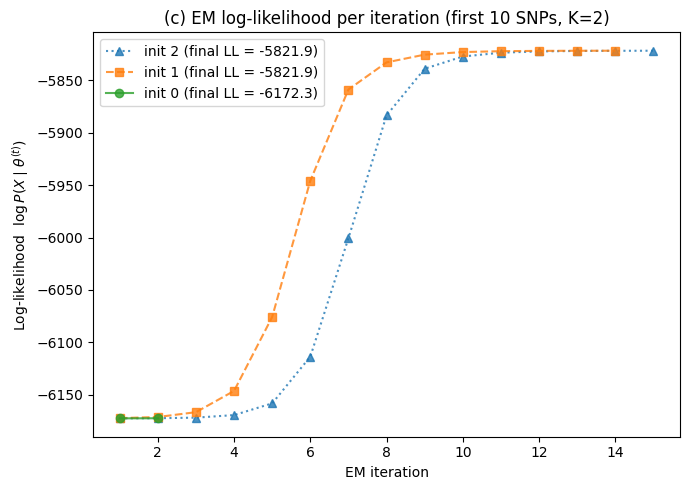

In [9]:
# Fit the full EM model on the first 10 SNPs of dataset 1, K = 2, all defaults
X10 = geno1[:, :10]
best_c, runs_c = fit_em(X10, K=2)

print('K = 2, first 10 SNPs of dataset 1')
for s, run in enumerate(runs_c):
    print(f"  init {s}: converged log-likelihood = {run['final_ll']:.2f}  "
          f"(iters = {len(run['ll_history'])}, pi = {np.round(run['pi'], 3)})")
print('\nBest (max-likelihood) restart log-likelihood:', round(float(best_c['final_ll']), 2))

# Plot the log-likelihood vs. iteration for all three random initializations.
# All restarts start near the same value, so we draw shorter runs on top (higher
# zorder) with distinct linestyles/markers so overlapping curves stay visible.
styles = ['-o', '--s', ':^']
fig, ax = plt.subplots(figsize=(7, 5))
order = sorted(range(len(runs_c)), key=lambda s: -len(runs_c[s]['ll_history']))
for z, s in enumerate(order):
    run = runs_c[s]
    iters = np.arange(1, len(run['ll_history']) + 1)
    ax.plot(iters, run['ll_history'], styles[s], ms=6, alpha=0.8, zorder=z + 2,
            label=f"init {s} (final LL = {run['final_ll']:.1f})")
ax.set_xlabel('EM iteration')
ax.set_ylabel('Log-likelihood  $\\log P(X\\mid\\theta^{(t)})$')
ax.set_title('(c) EM log-likelihood per iteration (first 10 SNPs, K=2)')
ax.legend()
plt.tight_layout()
plt.show()

**Answer (c).** As required, the log-likelihood is **monotonically non-decreasing** within every run, which confirms the E/M steps are implemented correctly. The three random initializations do **not** all reach the same fixed point: two of them climb to the good optimum (LL ≈ −5822) while one gets stuck early at a poorer local optimum (LL ≈ −6172, a near-symmetric solution with $\pi\approx(0.5,0.5)$). This is exactly why we use multiple random restarts and keep the run with the largest final log-likelihood as the final estimator.

## Part (d): EM solutions across initializations (K = 3)

We fit the full EM model again on the first 10 SNPs of dataset 1, this time with $K=3$ and everything else at the defaults, and report the converged log-likelihood of each of the three random initializations.

K = 3, first 10 SNPs of dataset 1
  init 0: converged log-likelihood = -5813.64  (iters = 25, pi = [0.396 0.352 0.252])
  init 1: converged log-likelihood = -5814.32  (iters = 20, pi = [0.256 0.547 0.197])
  init 2: converged log-likelihood = -5813.82  (iters = 29, pi = [0.336 0.264 0.4  ])

Best (max-likelihood) restart log-likelihood: -5813.64


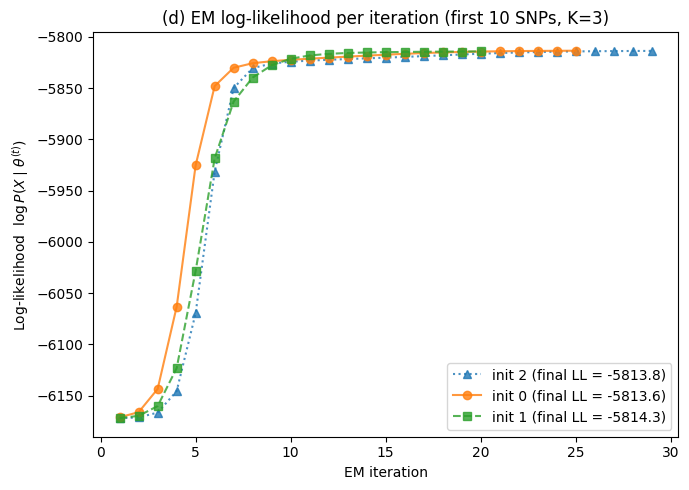

In [10]:
# Fit the full EM model on the first 10 SNPs of dataset 1 with K = 3
best_d, runs_d = fit_em(X10, K=3)

print('K = 3, first 10 SNPs of dataset 1')
for s, run in enumerate(runs_d):
    print(f"  init {s}: converged log-likelihood = {run['final_ll']:.2f}  "
          f"(iters = {len(run['ll_history'])}, pi = {np.round(run['pi'], 3)})")
print('\nBest (max-likelihood) restart log-likelihood:', round(float(best_d['final_ll']), 2))

# Plot the log-likelihood vs. iteration for all three random initializations
# (same style as part (c): shorter runs drawn on top with distinct linestyles)
styles = ['-o', '--s', ':^']
fig, ax = plt.subplots(figsize=(7, 5))
order = sorted(range(len(runs_d)), key=lambda s: -len(runs_d[s]['ll_history']))
for z, s in enumerate(order):
    run = runs_d[s]
    iters = np.arange(1, len(run['ll_history']) + 1)
    ax.plot(iters, run['ll_history'], styles[s], ms=6, alpha=0.8, zorder=z + 2,
            label=f"init {s} (final LL = {run['final_ll']:.1f})")
ax.set_xlabel('EM iteration')
ax.set_ylabel('Log-likelihood  $\\log P(X\\mid\\theta^{(t)})$')
ax.set_title('(d) EM log-likelihood per iteration (first 10 SNPs, K=3)')
ax.legend()
plt.tight_layout()
plt.show()

**Answer (d).** With $K=3$ the three random initializations all converge to essentially the **same** log-likelihood — approximately **−5813.6, −5814.3, and −5813.8** (best ≈ −5813.6). Unlike the $K=2$ case in part (c), no restart gets stuck at a noticeably worse optimum here; the optima differ only marginally (within ~1 log-likelihood unit, attributable to label permutations and slightly different soft partitions). Note also that the $K=3$ log-likelihood (≈ −5814) is higher than the $K=2$ optimum (≈ −5822): adding a third component can only increase the maximized likelihood, even though the data were generated from just 2 populations — a reminder that raw likelihood always favors larger $K$ and is not by itself a good criterion for choosing the number of clusters.

## Part (e): Concordance of inferred labels across initializations

We project all individuals onto the first two principal components — computed on the **full** set of 250 SNPs of dataset 1 — and color each point by the MAP ancestry label ($\arg\max_k r_{i,k}$) inferred by each of the three $K=3$ random initializations from part (d).

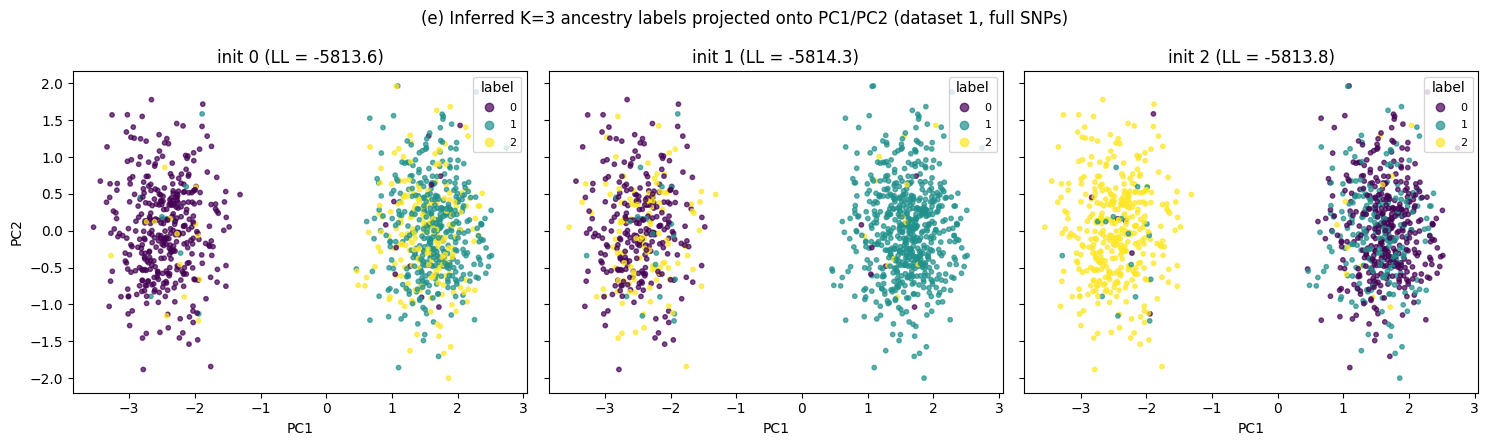

In [11]:
from sklearn.decomposition import PCA

# PCA on the full set of SNPs/features in dataset 1
pcs1 = PCA(n_components=2).fit_transform(geno1)   # (1000, 2)

# Color each individual by the MAP label from each K=3 random initialization (part d)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for s, (ax, run) in enumerate(zip(axes, runs_d)):
    labels = run['r'].argmax(axis=1)              # MAP ancestry label per individual
    sc = ax.scatter(pcs1[:, 0], pcs1[:, 1], c=labels, cmap='viridis', s=10, alpha=0.7)
    ax.set_xlabel('PC1')
    if s == 0:
        ax.set_ylabel('PC2')
    ax.set_title(f"init {s} (LL = {run['final_ll']:.1f})")
    ax.legend(*sc.legend_elements(), title='label', loc='upper right', fontsize=8)

fig.suptitle('(e) Inferred K=3 ancestry labels projected onto PC1/PC2 (dataset 1, full SNPs)')
plt.tight_layout()
plt.show()

**Answer (e).** In the PC1/PC2 projection the data clearly form **two** groups separated along PC1 (the two true populations), with no real sub-structure along PC2 — yet we asked EM for $K=3$ clusters. All three initializations agree on the dominant split (the left vs. right PC1 groups are always kept apart), so the genuine 2-population structure is recovered robustly. The **discrepancy** is in where each run places the *extra, third* cluster, which has no real signal to latch onto:

- **init 0** keeps the left PC1 group as one cluster and arbitrarily splits the **right** group into two;
- **init 1** instead keeps the right group whole and splits the **left** group into two;
- **init 2** again splits the **right** group, but with the colors/label identities permuted relative to init 0.

So the three solutions are **not concordant**: they disagree both on *which* true population gets subdivided and on the color/label assignment (label switching — the same physical cluster carries a different integer label across panels). This is the expected symptom of over-specifying $K$: the surplus component is unidentifiable and gets pinned to noise differently from each starting point, even though all runs reach nearly the same log-likelihood (part d). With the correct $K=2$ the inferred labels would instead be essentially identical (up to relabeling) across initializations.

## Part (f): Accuracy vs. number of SNPs

We run EM on dataset 1 with $K=2$ using the first 10, 25, 50, 100, 150, 200, and 250 SNPs (defaults otherwise). For each configuration we take the labels from the best random restart and compute the adjusted Rand score against the ground-truth ancestry, then plot accuracy as a function of the number of SNPs.

  first  10 SNPs: adjusted Rand score = 0.8682
  first  25 SNPs: adjusted Rand score = 0.9446
  first  50 SNPs: adjusted Rand score = 0.9761
  first 100 SNPs: adjusted Rand score = 0.9960
  first 150 SNPs: adjusted Rand score = 1.0000
  first 200 SNPs: adjusted Rand score = 1.0000
  first 250 SNPs: adjusted Rand score = 1.0000


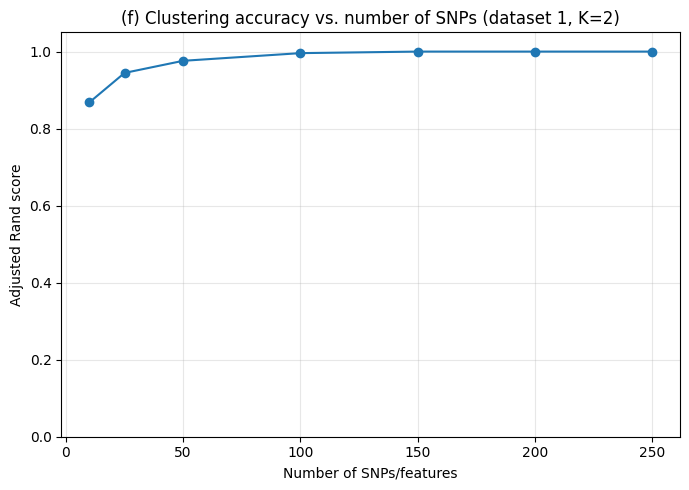

In [12]:
snp_counts = [10, 25, 50, 100, 150, 200, 250]
z_true = ganc1.argmax(axis=1)

ari_scores = []
for m in snp_counts:
    best_run, _ = fit_em(geno1[:, :m], K=2)          # best of 3 restarts
    z_hat = best_run['r'].argmax(axis=1)             # MAP labels
    ari = adjusted_rand_score(z_true, z_hat)
    ari_scores.append(ari)
    print(f"  first {m:3d} SNPs: adjusted Rand score = {ari:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(snp_counts, ari_scores, marker='o')
ax.set_xlabel('Number of SNPs/features')
ax.set_ylabel('Adjusted Rand score')
ax.set_title('(f) Clustering accuracy vs. number of SNPs (dataset 1, K=2)')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Answer (f).** The adjusted Rand score **increases monotonically with the number of SNPs**, rising steeply at first and then saturating: ≈0.87 with only 10 SNPs, ≈0.95 at 25, ≈0.98 at 50, ≈0.996 at 100, and reaching a perfect **1.0 by ~150 SNPs** (and staying there at 200 and 250). Each additional SNP contributes more information to distinguish the two populations, so the per-individual posteriors become sharper and the MAP labels match the truth almost perfectly. The diminishing returns past ~150 SNPs show that, for these two populations, a modest number of markers already suffices to recover ancestry essentially perfectly.

## Part (g): Choosing K on dataset 2

For dataset 2 (no ground truth), we fit EM for $K = 1, \dots, 5$ on the first 100 SNPs and, for each $K$, record the log-likelihood of the best random restart. We then plot the log-likelihood against $K$ and pick the number of components from the curve.

  K = 1: best log-likelihood = -56528.1
  K = 2: best log-likelihood = -53192.9
  K = 3: best log-likelihood = -53105.3
  K = 4: best log-likelihood = -53015.7
  K = 5: best log-likelihood = -52912.1


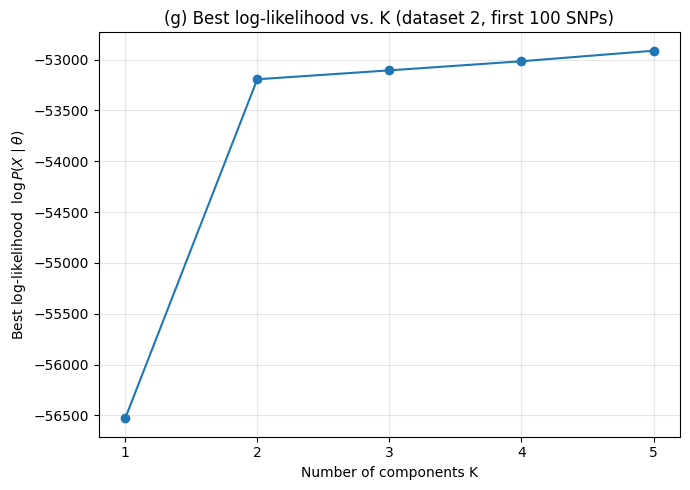

In [13]:
K_values = [1, 2, 3, 4, 5]
X2_100 = geno2[:, :100]            # first 100 SNPs of dataset 2

best_lls = []
for K in K_values:
    best_run, _ = fit_em(X2_100, K=K)      # best of 3 restarts
    best_lls.append(best_run['final_ll'])
    print(f"  K = {K}: best log-likelihood = {best_run['final_ll']:.1f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(K_values, best_lls, marker='o')
ax.set_xlabel('Number of components K')
ax.set_ylabel('Best log-likelihood  $\\log P(X\\mid\\theta)$')
ax.set_title('(g) Best log-likelihood vs. K (dataset 2, first 100 SNPs)')
ax.set_xticks(K_values)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Answer (g).** The log-likelihood always increases with $K$ (more components can only fit the data better), so we cannot just pick the largest $K$ — instead we look for the **elbow**, the point past which adding components yields only marginal gains. Here there is a large jump from $K=1$ (≈ −56528) to $K=2$ (≈ −53193), and then the curve flattens sharply: $K=3,4,5$ improve by only ~90–190 each, far less than the ~3300 gained at $K=2$. The elbow is clearly at $K=2$, so **I would choose $K=2$** — two populations best explain the structure in dataset 2, and the tiny extra gains beyond that reflect overfitting noise rather than real additional populations.

## Part (h): MLE of $\pi$ on dataset 2

We run EM on the **full** dataset 2 (all 250 SNPs) with $K=2$, keep the best of 3 random restarts, and report the MLE of the population proportions $\boldsymbol{\pi}$.

In [14]:
# Run EM on the full dataset 2 (all 250 SNPs) with K = 2
best_h, _ = fit_em(geno2, K=2)

pi_hat = np.sort(best_h['pi'])[::-1]   # sort for a stable, readable report (labels are arbitrary)
print('Full dataset 2, K = 2')
print('  best log-likelihood:', round(float(best_h['final_ll']), 1))
print('  MLE of pi:', np.round(pi_hat, 4))

Full dataset 2, K = 2
  best log-likelihood: -129163.6
  MLE of pi: [0.776 0.224]


**Answer (h).** Running EM on the full dataset 2 with $K=2$, the MLE of the population proportions is $\boldsymbol{\pi} \approx (0.776,\ 0.224)$ — i.e. the model infers an **unbalanced** mixture, with roughly 78% of individuals in the larger population and 22% in the smaller one. (The ordering of the two entries is arbitrary because of label switching; only the split itself is meaningful.)